**Mount**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Install**

In [ ]:
!pip install -U diffusers transformers accelerate torch torchvision python-Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 80.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/5

In [ ]:
pip install --upgrade torch torchvision diffusers transformers accelerate

In [ ]:
import transformers
print(transformers.__version__)

5.0.0


In [ ]:
pip install python-Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 17.1 MB/s eta 0:00:00


**Offline/Online (Intra User)**

In [ ]:
# =========================================================
# 1. SETUP, MODELS & CONFIG
# =========================================================
import torch
import numpy as np
import cv2
import os
import re
import pandas as pd
import random
from Levenshtein import ratio
from PIL import Image
from diffusers import AutoencoderKL
from diffusers.models.attention_processor import AttnProcessor
from torchvision import transforms
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from tqdm import tqdm
from itertools import combinations
from skimage.metrics import structural_similarity as ssim

# =========================
# DEVICE & DTYPE (FIX UTAMA)
# =========================
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32  # ❗ JANGAN DIOVERRIDE LAGI

# =========================
# LOAD MODELS
# =========================
processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")
trocr_model = VisionEncoderDecoderModel.from_pretrained(
    "microsoft/trocr-base-handwritten"
).to(device)

vae = AutoencoderKL.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    subfolder="vae",
    torch_dtype=dtype
).to(device)

vae.set_attn_processor(AttnProcessor())

# =========================================================
# 2. PATH CONFIG
# =========================================================
#offline
#input_folder = '/content/drive/MyDrive/DysgraphiaDB3/Offline_images/word_grade/grade2'
#output_folder = '/content/drive/MyDrive/DysgraphiaDB3/augmented/offline/intrauser/word_grade/grade2'
#online
input_folder = '/content/drive/MyDrive/DysgraphiaDB3/OnlineImage/pword/grade2'
output_folder = '/content/drive/MyDrive/DysgraphiaDB3/augmented/online/intrauser/pgrade/grade2'
#
os.makedirs(output_folder, exist_ok=True)
csv_path = os.path.join(output_folder, 'log_best_selection.csv')

IMG_SIZE = 256
threshold = 0.3
max_pairs_per_user = 10
targets = ["leto", "lamoken", "hračkárstvo"]

# =========================================================
# 3. HELPER FUNCTIONS
# =========================================================

def calculate_quality_score(img, ref1_path, ref2_path):
    try:
        r1 = cv2.resize(cv2.imread(ref1_path, 0), (IMG_SIZE, IMG_SIZE))
        r2 = cv2.resize(cv2.imread(ref2_path, 0), (IMG_SIZE, IMG_SIZE))
        return (ssim(img, r1) + ssim(img, r2)) / 2
    except:
        return 0.0


def get_unique_heterogeneous_decisions(n_patch, n_variations, device):
    decisions = []
    max_comb = (2**n_patch) - 2
    actual_variations = min(n_variations, max_comb) if max_comb > 0 else 1

    while len(decisions) < actual_variations:
        pattern = torch.randint(0, 2, (n_patch,), device=device)

        if n_patch > 1:
            if 0 < pattern.sum() < n_patch:
                if pattern.tolist() not in [d.tolist() for d in decisions]:
                    decisions.append(pattern)
        else:
            decisions.append(pattern)
            break

    return decisions


def run_trocr(path):
    try:
        img = Image.open(path).convert("RGB")
        pixel_values = processor(images=img, return_tensors="pt").pixel_values.to(device)

        ids = trocr_model.generate(pixel_values, max_length=15, num_beams=5)
        text = processor.batch_decode(ids, skip_special_tokens=True)[0]

        return re.sub(r'[^a-zA-Z]', '', text).lower()
    except:
        return None


def get_dynamic_npatch(pred_text):
    best_target = None
    best_score = 0

    for t in targets:
        score = ratio(pred_text, t)
        if score > best_score:
            best_score = score
            best_target = t

    if best_target is None:
        return 4, None

    return len(best_target), best_target


# =========================================================
# 4. MAIN PROCESS
# =========================================================

all_files = sorted([
    f for f in os.listdir(input_folder)
    if f.lower().endswith(('.png', '.jpg'))
])

# GROUP BY USER
user_groups = {}
for f in all_files:
    uid = f[:9]
    user_groups.setdefault(uid, []).append(f)

log_data = []

# =========================
# TRANSFORM (FIX NORMALIZE RGB)
# =========================
tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])  # ❗ penting (RGB)
])

pbar = tqdm(user_groups.items())

for uid, files in pbar:
    if len(files) < 2:
        continue

    pbar.set_description(f"User: {uid}")

    for f1, f2 in combinations(files, 2):

        p1 = os.path.join(input_folder, f1)
        p2 = os.path.join(input_folder, f2)

        txt1 = run_trocr(p1)
        txt2 = run_trocr(p2)

        if not txt1 or not txt2:
            continue

        np1, task1 = get_dynamic_npatch(txt1)
        np2, task2 = get_dynamic_npatch(txt2)

        Npatch = max(np1, np2)

        print(f"{uid} | {task1} | {task2}")

        img1 = Image.open(p1).resize((IMG_SIZE, IMG_SIZE)).convert("RGB")
        img2 = Image.open(p2).resize((IMG_SIZE, IMG_SIZE)).convert("RGB")

        variations = []

        with torch.no_grad():

            # =========================
            # FIX DTYPE DI SINI
            # =========================
            l1 = vae.encode(
                tf(img1).unsqueeze(0).to(device, dtype=dtype)
            ).latent_dist.sample()

            l2 = vae.encode(
                tf(img2).unsqueeze(0).to(device, dtype=dtype)
            ).latent_dist.sample()

            all_dec = get_unique_heterogeneous_decisions(Npatch, 2, device)

            for dec in all_dec:

                seg_w = l1.shape[3] // Npatch
                mixed = torch.zeros_like(l1)

                for i in range(Npatch):
                    xs = i * seg_w
                    xe = (i + 1) * seg_w if i < Npatch - 1 else l1.shape[3]

                    mixed[:, :, :, xs:xe] = (
                        l2[:, :, :, xs:xe] if dec[i] == 1 else l1[:, :, :, xs:xe]
                    )

                decoded = vae.decode(mixed).sample

                out = (decoded.detach().cpu().squeeze().float().numpy() + 1) / 2
                out = np.clip(out * 255, 0, 255).astype(np.uint8)

                res_gray = cv2.cvtColor(out.transpose(1, 2, 0), cv2.COLOR_RGB2GRAY)

                # =========================
                # NEAREST NEIGHBOR FILTER
                # =========================
                final_canvas = np.ones((IMG_SIZE, IMG_SIZE), dtype=np.uint8) * 255
                roi_w = IMG_SIZE // Npatch

                for s in range(Npatch):
                    ixs = s * roi_w
                    ixe = (s + 1) * roi_w if s < Npatch - 1 else IMG_SIZE

                    roi = res_gray[:, ixs:ixe]

                    mask_h = cv2.inRange(roi, 0, 110)
                    mask_a = cv2.inRange(roi, 111, 220)

                    M = cv2.moments(mask_h)

                    if M["m00"] == 0:
                        ref_x, ref_y = roi_w // 2, IMG_SIZE // 2
                    else:
                        ref_x = int(M["m10"] / M["m00"])
                        ref_y = int(M["m01"] / M["m00"])

                    cnts, _ = cv2.findContours(mask_a, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

                    sel_abu = np.zeros_like(roi)

                    if cnts:
                        best = min(
                            cnts,
                            key=lambda c: np.sqrt(
                                ((cv2.moments(c)["m10"] / (cv2.moments(c)["m00"] + 1e-5)) - ref_x) ** 2 +
                                ((cv2.moments(c)["m01"] / (cv2.moments(c)["m00"] + 1e-5)) - ref_y) ** 2
                            )
                        )
                        cv2.drawContours(sel_abu, [best], -1, 255, -1)

                    final_canvas[:, ixs:ixe] = cv2.bitwise_not(
                        cv2.bitwise_or(mask_h, sel_abu)
                    )

                variations.append({
                    'img': final_canvas,
                    'score': calculate_quality_score(final_canvas, p1, p2),
                    'dec': dec.tolist()
                })

        # =========================
        # SORT & SAVE
        # =========================
        variations.sort(key=lambda x: x['score'], reverse=True)

        for i in range(min(1, len(variations))):
            fname = f"mix_{f1[:11]}_{f2[-8:-4]}_{task1}_top{i+1}"

            cv2.imwrite(
                os.path.join(output_folder, f"{fname}.png"),
                variations[i]['img']
            )

            log_data.append({
                'User': uid,
                'img1': f1,
                'img2': f2,
                "prediction1": txt1,
                "prediction2": txt2,
                #'Rank': i + 1,
                'similarity': variations[i]['score'],
                #'Pattern': variations[i]['dec'],
                'canvas': fname
            })

# SAVE CSV
pd.DataFrame(log_data).to_csv(csv_path, index=False)

print(f"\nSelesai! {len(log_data)} gambar tersimpan.")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change an

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

User: user00008:   0%|          | 0/18 [00:00<?, ?it/s]

...

User: user00022:  17%|█▋        | 3/18 [09:08<45:13, 180.92s/it]

user00022 | lamoken | lamoken
user00022 | lamoken | lamoken
user00022 | lamoken | lamoken


User: user00032:  22%|██▏       | 4/18 [11:59<41:18, 177.01s/it]

user00032 | lamoken | lamoken
user00032 | lamoken | leto
user00032 | lamoken | lamoken
user00032 | lamoken | leto
user00032 | lamoken | lamoken
user00032 | leto | lamoken


User: user00038:  28%|██▊       | 5/18 [17:38<50:59, 235.31s/it]

 **Offline/Online (Inter User)**

In [ ]:
import os
import re
import cv2
import numpy as np
import pandas as pd
from PIL import Image
import torch
import random
from difflib import SequenceMatcher
from diffusers import AutoencoderKL
from diffusers.models.attention_processor import AttnProcessor
from torchvision import transforms
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from tqdm import tqdm

# =========================
# CONFIGURATION
# =========================
IMG_SIZE = 256
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float32
print(f"Device: {device}")

input_folder = '/content/drive/MyDrive/DysgraphiaDB3/Offline_images/dword_grade/grade2'
output_csv = '/content/drive/MyDrive/DysgraphiaDB3/augmented/offline/-interuser/dword_grade/grade2/hasil_trocr_augmented.csv'
output_img_dir = '/content/drive/MyDrive/DysgraphiaDB3/augmented/offline/-interuser/dword_grade/grade2'
os.makedirs(output_img_dir, exist_ok=True)

targets = ["leto", "lamoken", "hračkárstvo"]

# =========================
# HELPER: RESIZE & PAD
# =========================
def resize_and_pad(img, size=256):
    w, h = img.size
    scale = min(size/w, size/h)
    new_w, new_h = int(w * scale), int(h * scale)
    img_resized = img.resize((new_w, new_h), Image.Resampling.LANCZOS)
    new_img = Image.new("RGB", (size, size), (255, 255, 255))
    left, top = (size - new_w) // 2, (size - new_h) // 2
    new_img.paste(img_resized, (left, top))
    return new_img

# =========================
# LOAD MODELS
# =========================
vae = AutoencoderKL.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    subfolder="vae",
    torch_dtype=dtype
).to(device)

vae.set_attn_processor(AttnProcessor())
vae.eval()

processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")
trocr_model = VisionEncoderDecoderModel.from_pretrained(
    "microsoft/trocr-base-handwritten"
).to(device)
trocr_model.eval()

tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# =========================
# FUNCTIONS
# =========================
def run_trocr(img_pil):
    try:
        pixel_values = processor(images=img_pil, return_tensors="pt").pixel_values.to(device)
        generated_ids = trocr_model.generate(
            pixel_values,
            max_length=15,
            num_beams=5,
            early_stopping=True
        )
        text = processor.batch_decode(generated_ids, skip_special_tokens=True)
        return text[0].strip() if isinstance(text, list) else str(text).strip()
    except:
        return None

def similarity(a, b):
    return SequenceMatcher(None, a, b).ratio()

def get_dynamic_npatch(pred_text, targets):
    best_target = max(targets, key=lambda t: similarity(pred_text, t))
    return len(best_target), best_target

def get_unique_heterogeneous_decisions(n_patch, n_variations, device):
    decisions = []
    while len(decisions) < n_variations:
        pattern = torch.randint(0, 2, (n_patch,), device=device)
        if pattern.sum() > 0 and pattern.sum() < n_patch:
            if pattern.tolist() not in [d.tolist() for d in decisions]:
                decisions.append(pattern)
    return decisions

# =========================
# PRE-CACHE IMAGES
# =========================
files = sorted([
    f for f in os.listdir(input_folder)
    if f.lower().endswith(('.png','.jpg','.jpeg'))
])

print("Preprocessing images...")
processed_images = {}

for f in tqdm(files):
    path = os.path.join(input_folder, f)
    processed_images[f] = resize_and_pad(
        Image.open(path).convert("RGB"),
        IMG_SIZE
    )

# =========================
# MAIN LOOP
# =========================
results = []

for f1 in tqdm(files, desc="Processing"):
    img1_pil = processed_images[f1]
    txt1 = run_trocr(img1_pil)

    if not txt1:
        continue

    clean_txt1 = re.sub(r'[^a-zA-Z]', '', txt1).lower()
    np1, _ = get_dynamic_npatch(clean_txt1, targets)

    best_score_f1 = -1
    best_data_f1 = None

    for f2 in random.sample(files, min(len(files), 5)):
        if f1 == f2:
            continue

        img2_pil = processed_images[f2]
        Npatch = max(np1, 4)

        with torch.no_grad():
            l1 = vae.encode(tf(img1_pil).unsqueeze(0).to(device, dtype=dtype)).latent_dist.sample()
            l2 = vae.encode(tf(img2_pil).unsqueeze(0).to(device, dtype=dtype)).latent_dist.sample()

            # =========================
            # FIXED SECTION SPLIT
            # =========================
            sections = np.array_split(np.arange(l1.shape[-1]), Npatch)

            # =========================
            # FIXED DECISION
            # =========================
            dec = get_unique_heterogeneous_decisions(Npatch, 1, device)[0]

            mixed = l1.clone()

            for i, section in enumerate(sections):
                if dec[i] == 1:
                    start = int(section[0])
                    end = int(section[-1]) + 1
                    mixed[:, :, :, start:end] = l2[:, :, :, start:end]

            # =========================
            # DECODE
            # =========================
            decoded = vae.decode(mixed).sample
            out = (decoded.detach().cpu().squeeze().float().numpy() + 1) / 2

            img_rgb = np.clip(out * 255, 0, 255).astype(np.uint8).transpose(1,2,0)
            res_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

            # =========================
            # SIMPLE POSTPROCESS
            # =========================
            _, thresh = cv2.threshold(res_gray, 200, 255, cv2.THRESH_BINARY_INV)

            final_canvas = np.ones((IMG_SIZE, IMG_SIZE), dtype=np.uint8) * 255
            final_canvas[thresh > 0] = 0

            # =========================
            # TROCR EVALUATION
            # =========================
            pred_aug = run_trocr(Image.fromarray(final_canvas))
            if not pred_aug:
                continue

            clean_pred = re.sub(r'[^a-zA-Z]', '', pred_aug).lower()
            best_target = max(targets, key=lambda t: similarity(clean_pred, t))
            score = similarity(clean_pred, best_target)

            if score > best_score_f1:
                best_score_f1 = score
                best_data_f1 = {
                    "img1": f1,
                    "img2": f2,
                    "prediction": clean_pred,
                    "best_target": best_target,
                    "similarity": round(score, 3),
                    "canvas": final_canvas
                }

    if best_data_f1:
        save_path = os.path.join(output_img_dir, f"best_{f1}")
        cv2.imwrite(save_path, best_data_f1["canvas"])

        best_data_f1["image_path"] = save_path
        del best_data_f1["canvas"]

        results.append(best_data_f1)

# =========================
# SAVE CSV
# =========================
pd.DataFrame(results).to_csv(output_csv, index=False)

print("Selesai!")

Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Preprocessing images...


Processing:  25%|██▌       | 13/52 [00:39<01:53,  2.91s/it]

**Online (Image Raw)**

In [ ]:
# =========================================================
# 1. SETUP, MODELS & CONFIG
# =========================================================
import torch
import numpy as np
import cv2
import os
import re
import pandas as pd
import random
from Levenshtein import ratio
from PIL import Image
from diffusers import AutoencoderKL
from diffusers.models.attention_processor import AttnProcessor
from torchvision import transforms
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from tqdm import tqdm
from itertools import combinations
from skimage.metrics import structural_similarity as ssim

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

# Load Models
processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")
trocr_model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-handwritten").to(device)

vae = AutoencoderKL.from_pretrained("runwayml/stable-diffusion-v1-5", subfolder="vae", torch_dtype=dtype).to(device)
vae.set_attn_processor(AttnProcessor())

#=============================================
#GANTI NAMA FOLDER TUJUAN DAN KONVERSI CITRA
#=============================================
input_folder = '/content/drive/MyDrive/DysgraphiaDB3/OnlineImage/pword/normal'
output_folder = '/content/drive/MyDrive/DysgraphiaDB3/Augmented/Online/pword/normal'
csv_path = os.path.join(output_folder, 'log_best_selection.csv')
if not os.path.exists(output_folder): os.makedirs(output_folder)

IMG_SIZE = 256
dtype = torch.float32
threshold = 0.3
max_pairs_per_user = 10
max_decisions = 10
targets = ["leto", "lamoken", "hračkárstve"]

path_parts = input_folder.split('/')
current_grade = int(''.join(filter(str.isdigit, path_parts[-1]))) if any(char.isdigit() for char in path_parts[-1]) else 0

# =========================================================
# 2. HELPER FUNCTIONS
# =========================================================

def calculate_quality_score(img, ref1_path, ref2_path):
    try:
        r1 = cv2.resize(cv2.imread(ref1_path, 0), (IMG_SIZE, IMG_SIZE))
        r2 = cv2.resize(cv2.imread(ref2_path, 0), (IMG_SIZE, IMG_SIZE))
        return (ssim(img, r1) + ssim(img, r2)) / 2
    except: return 0.0

def get_unique_heterogeneous_decisions(n_patch, n_variations, device):
    decisions = []
    max_comb = (2**n_patch) - 2
    actual_variations = min(n_variations, max_comb) if max_comb > 0 else 1
    while len(decisions) < actual_variations:
        pattern = torch.randint(0, 2, (n_patch,), device=device)
        if n_patch > 1:
            if pattern.sum() > 0 and pattern.sum() < n_patch:
                if pattern.tolist() not in [d.tolist() for d in decisions]: decisions.append(pattern)
        else: decisions.append(pattern); break
    return decisions


def run_trocr(path):
    try:
        img = Image.open(path).convert("RGB")
        pixel_values = processor(images=img, return_tensors="pt").pixel_values.to(device)

        ids = trocr_model.generate(pixel_values, max_length=15, num_beams=5)
        text = processor.batch_decode(ids, skip_special_tokens=True)[0]

        return re.sub(r'[^a-zA-Z]', '', text).lower()
    except:
        return None

def get_dynamic_npatch(pred_text):
    best_target = None
    best_score = 0

    for t in targets:
        score = ratio(pred_text, t)
        if score > best_score:
            best_score = score
            best_target = t

    if best_target is None:
        return 4, None

    return len(best_target), best_target



# =========================================================
# 3. MAIN PROCESS
# =========================================================
all_files = sorted([f for f in os.listdir(input_folder) if f.lower().endswith(('.png', '.jpg'))])
user_groups = {}
for f in all_files:
    uid = f[:9]
    if uid not in user_groups: user_groups[uid] = []
    user_groups[uid].append(f)

log_data = []
tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize([0.5], [0.5])])
pbar = tqdm(user_groups.items())

for uid, files in pbar:
    if len(files) < 2: continue
    pbar.set_description(f"User: {uid}")

    # Ambil HANYA pasangan pertama untuk tes kecepatan (opsional)
    for f1, f2 in combinations(files, 2):
        p1 = os.path.join(input_folder, f1)
        p2 = os.path.join(input_folder, f2)
        txt1 = run_trocr(p1)
        txt2 = run_trocr(p2)
        if not txt1 or not txt2:
            continue

        np1, _ = get_dynamic_npatch(txt1)
        np2, _ = get_dynamic_npatch(txt2)
        _, task1  = get_dynamic_npatch(txt1)
        _, task2  = get_dynamic_npatch(txt2)
        Npatch = max(np1, np2)
        print(f"{uid} | {task1} | {task2}")

        img1 = Image.open(p1).resize((IMG_SIZE, IMG_SIZE)).convert("RGB")
        img2 = Image.open(p2).resize((IMG_SIZE, IMG_SIZE)).convert("RGB")

        variations = []
        with torch.no_grad():
            l1 = vae.encode(tf(img1).unsqueeze(0).to(device, dtype=dtype)).latent_dist.sample()
            l2 = vae.encode(tf(img2).unsqueeze(0).to(device, dtype=dtype)).latent_dist.sample()
            all_dec = get_unique_heterogeneous_decisions(Npatch, 2, device)

            for v_idx, dec in enumerate(all_dec):
                seg_w = l1.shape[3] // Npatch
                mixed = torch.zeros_like(l1)
                for i in range(Npatch):
                    xs = i * seg_w
                    xe = (i + 1) * seg_w if i < Npatch-1 else l1.shape[3]
                    mixed[:, :, :, xs:xe] = l2[:, :, :, xs:xe] if dec[i] == 1 else l1[:, :, :, xs:xe]

                decoded = vae.decode(mixed).sample
                out = (decoded.detach().cpu().squeeze().float().numpy() + 1) / 2
                res_gray = cv2.cvtColor(np.clip(out*255, 0, 255).astype(np.uint8).transpose(1, 2, 0), cv2.COLOR_RGB2GRAY)

                # --- NEAREST NEIGHBOR FILTER ---
                final_canvas = np.ones((IMG_SIZE, IMG_SIZE), dtype=np.uint8) * 255
                roi_w = IMG_SIZE // Npatch
                for s in range(Npatch):
                    ixs, ixe = s * roi_w, (s + 1) * roi_w if s < Npatch-1 else IMG_SIZE
                    roi = res_gray[:, ixs:ixe]
                    mask_h, mask_a = cv2.inRange(roi, 0, 110), cv2.inRange(roi, 111, 220)
                    M = cv2.moments(mask_h)
                    ref_x, ref_y = (roi_w//2, IMG_SIZE//2) if M["m00"] == 0 else (int(M["m10"]/M["m00"]), int(M["m01"]/M["m00"]))
                    cnts, _ = cv2.findContours(mask_a, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                    sel_abu = np.zeros_like(roi)
                    if cnts:
                        best = min(cnts, key=lambda c: np.sqrt((cv2.moments(c)["m10"]/(cv2.moments(c)["m00"]+1e-5) - ref_x)**2 + (cv2.moments(c)["m01"]/(cv2.moments(c)["m00"]+1e-5) - ref_y)**2))
                        cv2.drawContours(sel_abu, [best], -1, 255, -1)
                    final_canvas[:, ixs:ixe] = cv2.bitwise_not(cv2.bitwise_or(mask_h, sel_abu))

                variations.append({'img': final_canvas, 'score': calculate_quality_score(final_canvas, p1, p2), 'dec': dec.tolist()})

        # SORT & SAVE TOP 2
        variations.sort(key=lambda x: x['score'], reverse=True)
        for i in range(min(1, len(variations))):
            best_img = variations[i]['img']
            # Nama file diperpendek agar tidak terlalu panjang
            fname = f"mix_{f1[:11]}_{f2[-8:-4]}_{task1}_top{i+1}"
            cv2.imwrite(os.path.join(output_folder, f"{fname}.png"), best_img)
            log_data.append({'User': uid, 'Pair': f"{f1}x{f2}", 'Rank': i+1, 'Score': variations[i]['score'], 'Pattern': variations[i]['dec']})

pd.DataFrame(log_data).to_csv(csv_path, index=False)
print(f"\nSelesai! {len(log_data)} Gambar terbaik tersimpan.")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

KeyboardInterrupt: 

klasifikasi

**Baseline**



1.   pairing
2.   akumulasi semua prediksi
3.   1 conv matriks besar
4.   precision, recall, f1 per class/ class
5.   Accuracy, Kappa, Report, CM
6.   **Meta learning**
7.   *belum cek nilai per fold*



**BASELINE FIX META LEARNING**

In [ ]:
# =========================================================
# MULTIMODAL DYSGRAPHIA - META LEARNING (STACKING)
# STRATIFIED 10-FOLD CV
# ONLINE SVM + OFFLINE SVM → META SVM
# =========================================================

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from PIL import Image
from torchvision import transforms, models

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, cohen_kappa_score
from sklearn.metrics import classification_report, confusion_matrix

# =========================
# DEVICE
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ONLINE_ROOT = "/content/drive/MyDrive/DysgraphiaDB3/Online"
OFFLINE_ROOT = "/content/drive/MyDrive/DysgraphiaDB3/Offline_images"

# =========================
# PARAMETER (TABLE II & III)
# =========================
svm_online_params = {
    "pword": {"C":4, "gamma":0.015625, "kernel":"rbf"},
    "word": {"C":16, "gamma":0.015625, "kernel":"rbf"},
    "dword": {"C":4, "gamma":0.015625, "kernel":"rbf"}
}

svm_offline_params = {
    "pword": {"C":0.001953125, "gamma":0.015625, "kernel":"poly"},
    "word": {"C":0.001953125, "gamma":0.001953125, "kernel":"poly"},
    "dword": {"C":0.00390625, "gamma":0.0078125, "kernel":"poly"}
}

# =========================
# ONLINE FEATURE
# =========================
def extract_online_features(path):
    import numpy as np
    import pandas as pd

    data = pd.read_csv(path, sep=r"\s+", header=None)

    # =========================
    # BASIC SIGNAL
    # =========================
    x = data.iloc[:,0].values
    y = data.iloc[:,1].values
    t = data.iloc[:,2].values + 1e-5

    pressure = data.iloc[:,3].values if data.shape[1] > 3 else np.zeros(len(x))
    altitude = data.iloc[:,4].values if data.shape[1] > 4 else np.zeros(len(x))
    azimuth  = data.iloc[:,5].values if data.shape[1] > 5 else np.zeros(len(x))

    # =========================
    # DERIVATIVES
    # =========================
    vx = np.diff(x) / np.diff(t)
    vy = np.diff(y) / np.diff(t)
    v  = np.sqrt(vx**2 + vy**2)

    ax = np.diff(vx) / np.diff(t[:-1])
    ay = np.diff(vy) / np.diff(t[:-1])
    a  = np.sqrt(ax**2 + ay**2)

    jx = np.diff(ax) / np.diff(t[:-2])
    jy = np.diff(ay) / np.diff(t[:-2])
    j  = np.sqrt(jx**2 + jy**2)

    # =========================
    # GEOMETRY
    # =========================
    seg_len = np.sqrt(np.diff(x)**2 + np.diff(y)**2)

    total_length = np.sum(seg_len)
    length_x = np.sum(np.abs(np.diff(x)))
    length_y = np.sum(np.abs(np.diff(y)))
    duration = t[-1] - t[0]

    width  = np.max(x) - np.min(x)
    height = np.max(y) - np.min(y)

    # =========================
    # HELPER STATISTICS
    # =========================
    def stats(arr):
        if len(arr) == 0:
            return [0]*7
        return [
            np.mean(arr),
            np.std(arr),
            np.min(arr),
            np.max(arr),
            np.median(arr),
            np.percentile(arr, 25),
            np.percentile(arr, 75)
        ]

    features = []

    # =========================
    # TIME-SERIES FEATURES (~100+)
    # =========================
    features += stats(vx)
    features += stats(vy)
    features += stats(v)

    features += stats(ax)
    features += stats(ay)
    features += stats(a)

    features += stats(jx)
    features += stats(jy)
    features += stats(j)

    # =========================
    # GEOMETRIC FEATURES
    # =========================
    features += stats(seg_len)

    features += [
        total_length,
        length_x,
        length_y,
        duration,
        width,
        height
    ]

    # =========================
    # PRESSURE & ANGLE
    # =========================
    features += stats(pressure)
    features += stats(altitude)
    features += stats(azimuth)

    # =========================
    # EXTRA DYNAMICS
    # =========================
    # velocity change count (local extrema)
    def count_extrema(arr):
        if len(arr) < 3:
            return 0
        return np.sum(
            (arr[1:-1] > arr[:-2]) & (arr[1:-1] > arr[2:]) |
            (arr[1:-1] < arr[:-2]) & (arr[1:-1] < arr[2:])
        )

    features += [
        count_extrema(v),
        count_extrema(a),
        count_extrema(j)
    ]

    # pen lifts (approx: t gap besar)
    dt = np.diff(t)
    pen_lift = np.sum(dt > np.mean(dt) * 3)
    features.append(pen_lift)

    # =========================
    # FINAL VECTOR
    # =========================
    return np.array(features)

# =========================
# CNN FEATURE
# =========================
class CNNFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.densenet121(pretrained=True)
        self.features = base.features
        self.pool = nn.AdaptiveAvgPool2d((1,1))

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return torch.flatten(x,1)

transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

def extract_cnn(paths, model):
    feats = []
    model.eval()
    with torch.no_grad():
        for p in paths:
            img = Image.open(p).convert("RGB")
            img = transform(img).unsqueeze(0).to(device)
            feats.append(model(img).cpu().numpy().flatten())
    return np.array(feats)

# =========================
# LOAD DATA (PAIRING)
# =========================
def load_paired_data(online_root, offline_root):
    X_online, X_img, y = [], [], []
    label_map = {"normal":0,"grade1":1,"grade2":2}

    for task in ["word","pword","dword"]:
        for cls in os.listdir(os.path.join(online_root, task)):

            online_dir = os.path.join(online_root, task, cls)
            offline_dir = os.path.join(offline_root, task, cls)

            if not os.path.exists(offline_dir):
                continue

            for f in os.listdir(online_dir):
                if not f.endswith(".txt"):
                    continue

                base = os.path.splitext(f)[0]
                img_path = os.path.join(offline_dir, base + ".png")

                if os.path.exists(img_path):
                    try:
                        X_online.append(extract_online_features(os.path.join(online_dir, f)))
                        X_img.append(img_path)
                        y.append(label_map[cls])
                    except:
                        continue

    return np.array(X_online), X_img, np.array(y)

# =========================
# MAIN
# =========================
X_online, X_img, y = load_paired_data(ONLINE_ROOT, OFFLINE_ROOT)

cnn_model = CNNFeatureExtractor().to(device)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

tasks = ["word","pword","dword"]

for task in tasks:
    print(f"\n=== {task.upper()} ===")

    idx = [i for i,p in enumerate(X_img) if f"/{task}/" in p]

    X = X_online[idx]
    y_task = y[idx]
    img_task = [X_img[i] for i in idx]

    y_true_all = []
    y_pred_all = []

    for train_idx, test_idx in skf.split(X, y_task):

        # =========================
        # ONLINE MODEL
        # =========================
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X[train_idx])
        X_test  = scaler.transform(X[test_idx])

        y_train = y_task[train_idx]
        y_test  = y_task[test_idx]

        svm_online = SVC(**svm_online_params[task], probability=True)
        svm_online.fit(X_train, y_train)

        prob_online_train = svm_online.predict_proba(X_train)
        prob_online_test  = svm_online.predict_proba(X_test)

        # =========================
        # OFFLINE MODEL
        # =========================
        img_train = [img_task[i] for i in train_idx]
        img_test  = [img_task[i] for i in test_idx]

        X_train_cnn = extract_cnn(img_train, cnn_model)
        X_test_cnn  = extract_cnn(img_test, cnn_model)

        scaler2 = StandardScaler()
        X_train_cnn = scaler2.fit_transform(X_train_cnn)
        X_test_cnn  = scaler2.transform(X_test_cnn)

        svm_offline = SVC(**svm_offline_params[task], probability=True)
        svm_offline.fit(X_train_cnn, y_train)

        prob_offline_train = svm_offline.predict_proba(X_train_cnn)
        prob_offline_test  = svm_offline.predict_proba(X_test_cnn)

        # =========================
        # META LEARNING (STACKING)
        # =========================
        meta_X_train = np.hstack([prob_online_train, prob_offline_train])
        meta_X_test  = np.hstack([prob_online_test, prob_offline_test])

        meta_model = SVC(kernel='rbf', C=1)
        meta_model.fit(meta_X_train, y_train)

        pred = meta_model.predict(meta_X_test)

        y_true_all.extend(y_test)
        y_pred_all.extend(pred)

    # =========================
    # FINAL RESULT (AKUMULASI)
    # =========================
    acc = accuracy_score(y_true_all, y_pred_all)
    kappa = cohen_kappa_score(y_true_all, y_pred_all)

    print("\n===== FINAL RESULT =====")
    print("Accuracy :", round(acc,4))
    print("Kappa    :", round(kappa,4))

    print("\nClassification Report:")
    print(classification_report(y_true_all, y_pred_all))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true_all, y_pred_all))

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



=== WORD ===

===== FINAL RESULT =====
Accuracy : 0.8071
Kappa    : 0.688

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.83      0.87       199
           1       0.70      0.79      0.74       126
           2       0.78      0.75      0.76        69

    accuracy                           0.81       394
   macro avg       0.79      0.79      0.79       394
weighted avg       0.82      0.81      0.81       394


Confusion Matrix:
[[166  30   3]
 [ 14 100  12]
 [  4  13  52]]

=== PWORD ===

===== FINAL RESULT =====
Accuracy : 0.8457
Kappa    : 0.7398

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       186
           1       0.77      0.79      0.78       105
           2       0.78      0.68      0.73        59

    accuracy                           0.85       350
   macro avg       0.82      0.80      0.81       350
weighted avg       0.84     

**uji coba meta learning dengan SVM **

Sampel akurasi word
1.   Pendekatan One-vs-One (OvO) tidak ada beda dengan One-vs-Rest (OvR) di meta learner word 0.8071 (decision_function_shape='ovo')
2.   class_weight='balanced' di meta learner turun ~0.003% word 0.8041
3.   class_weight='balanced' di base model turun ~3% word 0.7716
4.    Komparasi resnet50 (0.7944) dencenet121 (0.8071) dan efficientNet b7 (Accuracy : 0.802)
5.    



In [ ]:
# =========================================================
# MULTIMODAL DYSGRAPHIA - META LEARNING (STACKING)
# STRATIFIED 10-FOLD CV
# ONLINE SVM + OFFLINE SVM → META SVM
# =========================================================

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from PIL import Image
from torchvision import transforms, models

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, cohen_kappa_score
from sklearn.metrics import classification_report, confusion_matrix

# =========================
# DEVICE
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ONLINE_ROOT = "/content/drive/MyDrive/DysgraphiaDB3/Online"
OFFLINE_ROOT = "/content/drive/MyDrive/DysgraphiaDB3/Offline_images"

# =========================
# PARAMETER (TABLE II & III)
# =========================
svm_online_params = {
    "pword": {"C":4, "gamma":0.015625, "kernel":"rbf"},
    "word": {"C":16, "gamma":0.015625, "kernel":"rbf"},
    "dword": {"C":4, "gamma":0.015625, "kernel":"rbf"}
}

svm_offline_params = {
    "pword": {"C":0.001953125, "gamma":0.015625, "kernel":"poly"},
    "word": {"C":0.001953125, "gamma":0.001953125, "kernel":"poly"},
    "dword": {"C":0.00390625, "gamma":0.0078125, "kernel":"poly"}
}

# =========================
# ONLINE FEATURE
# =========================
def extract_online_features(path):
    import numpy as np
    import pandas as pd

    data = pd.read_csv(path, sep=r"\s+", header=None)

    # =========================
    # BASIC SIGNAL
    # =========================
    x = data.iloc[:,0].values
    y = data.iloc[:,1].values
    t = data.iloc[:,2].values + 1e-5

    pressure = data.iloc[:,3].values if data.shape[1] > 3 else np.zeros(len(x))
    altitude = data.iloc[:,4].values if data.shape[1] > 4 else np.zeros(len(x))
    azimuth  = data.iloc[:,5].values if data.shape[1] > 5 else np.zeros(len(x))

    # =========================
    # DERIVATIVES
    # =========================
    vx = np.diff(x) / np.diff(t)
    vy = np.diff(y) / np.diff(t)
    v  = np.sqrt(vx**2 + vy**2)

    ax = np.diff(vx) / np.diff(t[:-1])
    ay = np.diff(vy) / np.diff(t[:-1])
    a  = np.sqrt(ax**2 + ay**2)

    jx = np.diff(ax) / np.diff(t[:-2])
    jy = np.diff(ay) / np.diff(t[:-2])
    j  = np.sqrt(jx**2 + jy**2)

    # =========================
    # GEOMETRY
    # =========================
    seg_len = np.sqrt(np.diff(x)**2 + np.diff(y)**2)

    total_length = np.sum(seg_len)
    length_x = np.sum(np.abs(np.diff(x)))
    length_y = np.sum(np.abs(np.diff(y)))
    duration = t[-1] - t[0]

    width  = np.max(x) - np.min(x)
    height = np.max(y) - np.min(y)

    # =========================
    # HELPER STATISTICS
    # =========================
    def stats(arr):
        if len(arr) == 0:
            return [0]*7
        return [
            np.mean(arr),
            np.std(arr),
            np.min(arr),
            np.max(arr),
            np.median(arr),
            np.percentile(arr, 25),
            np.percentile(arr, 75)
        ]

    features = []

    # =========================
    # TIME-SERIES FEATURES (~100+)
    # =========================
    features += stats(vx)
    features += stats(vy)
    features += stats(v)

    features += stats(ax)
    features += stats(ay)
    features += stats(a)

    features += stats(jx)
    features += stats(jy)
    features += stats(j)

    # =========================
    # GEOMETRIC FEATURES
    # =========================
    features += stats(seg_len)

    features += [
        total_length,
        length_x,
        length_y,
        duration,
        width,
        height
    ]

    # =========================
    # PRESSURE & ANGLE
    # =========================
    features += stats(pressure)
    features += stats(altitude)
    features += stats(azimuth)

    # =========================
    # EXTRA DYNAMICS
    # =========================
    # velocity change count (local extrema)
    def count_extrema(arr):
        if len(arr) < 3:
            return 0
        return np.sum(
            (arr[1:-1] > arr[:-2]) & (arr[1:-1] > arr[2:]) |
            (arr[1:-1] < arr[:-2]) & (arr[1:-1] < arr[2:])
        )

    features += [
        count_extrema(v),
        count_extrema(a),
        count_extrema(j)
    ]

    # pen lifts (approx: t gap besar)
    dt = np.diff(t)
    pen_lift = np.sum(dt > np.mean(dt) * 3)
    features.append(pen_lift)

    # =========================
    # FINAL VECTOR
    # =========================
    return np.array(features)

# =========================
# CNN FEATURE
# =========================
class CNNFeatureExtractor(nn.Module):
    def __init__(self, model_name='densenet121'):
        super().__init__()
        # Mapping model ke arsitektur
        if model_name == 'densenet121':
            base = models.densenet121(pretrained=True)
            self.features = base.features
        elif model_name == 'resnet50':
            base = models.resnet50(pretrained=True)
            # ResNet memiliki layer terakhir yang perlu kita buang (fc layer)
            self.features = nn.Sequential(*list(base.children())[:-1])
        elif model_name == 'efficientnet_b7':
            base = models.efficientnet_b7(pretrained=True)
            self.features = base.features
        else:
            raise ValueError(f"Model {model_name} belum dikonfigurasi.")

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return torch.flatten(x,1)

transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

def extract_cnn(paths, model):
    feats = []
    model.eval()
    with torch.no_grad():
        for p in paths:
            img = Image.open(p).convert("RGB")
            img = transform(img).unsqueeze(0).to(device)
            feats.append(model(img).cpu().numpy().flatten())
    return np.array(feats)

# =========================
# LOAD DATA (PAIRING)
# =========================
def load_paired_data(online_root, offline_root):
    X_online, X_img, y = [], [], []
    label_map = {"normal":0,"grade1":1,"grade2":2}

    for task in ["word","pword","dword"]:
        for cls in os.listdir(os.path.join(online_root, task)):

            online_dir = os.path.join(online_root, task, cls)
            offline_dir = os.path.join(offline_root, task, cls)

            if not os.path.exists(offline_dir):
                continue

            for f in os.listdir(online_dir):
                if not f.endswith(".txt"):
                    continue

                base = os.path.splitext(f)[0]
                img_path = os.path.join(offline_dir, base + ".png")

                if os.path.exists(img_path):
                    try:
                        X_online.append(extract_online_features(os.path.join(online_dir, f)))
                        X_img.append(img_path)
                        y.append(label_map[cls])
                    except:
                        continue

    return np.array(X_online), X_img, np.array(y)

# =========================
# MAIN
# =========================
X_online, X_img, y = load_paired_data(ONLINE_ROOT, OFFLINE_ROOT)

#cnn_model = CNNFeatureExtractor('densenet121').to(device)
#cnn_model = CNNFeatureExtractor('resnet50').to(device)
cnn_model = CNNFeatureExtractor('efficientnet_b7').to(device)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

tasks = ["word","pword","dword"]

for task in tasks:
    print(f"\n=== {task.upper()} ===")

    idx = [i for i,p in enumerate(X_img) if f"/{task}/" in p]

    X = X_online[idx]
    y_task = y[idx]
    img_task = [X_img[i] for i in idx]

    y_true_all = []
    y_pred_all = []

    for train_idx, test_idx in skf.split(X, y_task):

        # =========================
        # ONLINE MODEL
        # =========================
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X[train_idx])
        X_test  = scaler.transform(X[test_idx])

        y_train = y_task[train_idx]
        y_test  = y_task[test_idx]

        svm_online = SVC(**svm_online_params[task], probability=True)
        svm_online.fit(X_train, y_train)

        prob_online_train = svm_online.predict_proba(X_train)
        prob_online_test  = svm_online.predict_proba(X_test)

        # =========================
        # OFFLINE MODEL
        # =========================
        img_train = [img_task[i] for i in train_idx]
        img_test  = [img_task[i] for i in test_idx]

        X_train_cnn = extract_cnn(img_train, cnn_model)
        X_test_cnn  = extract_cnn(img_test, cnn_model)

        scaler2 = StandardScaler()
        X_train_cnn = scaler2.fit_transform(X_train_cnn)
        X_test_cnn  = scaler2.transform(X_test_cnn)

        svm_offline = SVC(**svm_offline_params[task], probability=True)
        svm_offline.fit(X_train_cnn, y_train)

        prob_offline_train = svm_offline.predict_proba(X_train_cnn)
        prob_offline_test  = svm_offline.predict_proba(X_test_cnn)

        # =========================
        # META LEARNING (STACKING)
        # =========================
        meta_X_train = np.hstack([prob_online_train, prob_offline_train])
        meta_X_test  = np.hstack([prob_online_test, prob_offline_test])

        meta_model = SVC(kernel='rbf', C=1)
        meta_model.fit(meta_X_train, y_train)

        pred = meta_model.predict(meta_X_test)

        y_true_all.extend(y_test)
        y_pred_all.extend(pred)

    # =========================
    # FINAL RESULT (AKUMULASI)
    # =========================
    acc = accuracy_score(y_true_all, y_pred_all)
    kappa = cohen_kappa_score(y_true_all, y_pred_all)

    print("\n===== FINAL RESULT =====")
    print("Accuracy :", round(acc,4))
    print("Kappa    :", round(kappa,4))

    print("\nClassification Report:")
    print(classification_report(y_true_all, y_pred_all))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true_all, y_pred_all))

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B7_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B7_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



=== WORD ===


KeyboardInterrupt: 

In [ ]:
for fold, (train_idx, val_idx) in enumerate(skf.split(X_img, y)):
        print(f"--- Melatih Fold {fold+1}/{n_splits} ---")
        acc = accuracy_score(y_val_true[:len(y_val_pred)], y_val_pred)
        f1 = f1_score(y_val_true[:len(y_val_pred)], y_val_pred, average='weighted')

        results.append({"Fold": fold+1, "Accuracy": acc, "F1-Score": f1})

        # 3. Tampilkan hasil dalam bentuk tabel
        df_results = pd.DataFrame(results)
        print("\n--- Tabel Hasil Akhir ---")
        print(df_results)
        print(f"\nRata-rata Akurasi: {df_results['Accuracy'].mean():.4f}")
        print(f"Rata-rata F1-Score: {df_results['F1-Score'].mean():.4f}")

        return df_results

**Efficientnet B7+bilstm**

In [ ]:
# =========================================================
# MULTIMODAL DYSGRAPHIA - CLEAN FINAL PIPELINE
# FIX: NO RAW-FEATURE MIX, NO LEAKAGE, NO TYPE ERROR
# =========================================================

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image

from torchvision import transforms, models
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# =========================
# DEVICE
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================================================
# PATHS
# =========================================================
ONLINE_ROOT = "/content/drive/MyDrive/DysgraphiaDB3/Online"
OFFLINE_ROOT = "/content/drive/MyDrive/DysgraphiaDB3/Offline_images"

# =========================================================
# CNN MODEL
# =========================================================
class CNNFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.efficientnet_b7(weights='DEFAULT')
        self.features = base.features
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return torch.flatten(x, 1)

cnn_model = CNNFeatureExtractor().to(device)
cnn_model.eval()

# =========================================================
# LSTM FEATURE EXTRACTOR (UNTRAINED)
# =========================================================
class BiLSTMExtractor(nn.Module):
    def __init__(self, input_dim=5, hidden_dim=64):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim, hidden_dim,
            num_layers=2,
            batch_first=True,
            bidirectional=True
        )

    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        return torch.cat((hn[-2], hn[-1]), dim=1)

lstm_model = BiLSTMExtractor().to(device)
lstm_model.eval()

# =========================================================
# FEATURE FUNCTIONS (ONLY FOR PREPROCESSING STAGE)
# =========================================================

def extract_online_features(path):
    df = pd.read_csv(path, sep=r"\s+", header=None)

    x = df.iloc[:,0].values
    y = df.iloc[:,1].values
    t = df.iloc[:,2].values + 1e-5

    vx = np.diff(x) / np.diff(t)
    vy = np.diff(y) / np.diff(t)
    v = np.sqrt(vx**2 + vy**2)

    def stats(a):
        if len(a) == 0:
            return [0]*5
        return [
            np.mean(a),
            np.std(a),
            np.min(a),
            np.max(a),
            np.median(a)
        ]

    feat = []
    feat += stats(vx)
    feat += stats(vy)
    feat += stats(v)

    feat += [
        np.sum(np.sqrt(np.diff(x)**2 + np.diff(y)**2)),
        np.max(x)-np.min(x),
        np.max(y)-np.min(y)
    ]

    return np.array(feat)


def extract_cnn(paths):
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],
                             [0.229,0.224,0.225])
    ])

    feats = []
    with torch.no_grad():
        for p in paths:
            img = Image.open(p).convert("RGB")
            img = transform(img).unsqueeze(0).to(device)
            feats.append(cnn_model(img).cpu().numpy().flatten())

    return np.array(feats)


def load_sequence(path):
    df = pd.read_csv(path, sep=r"\s+", header=None)
    return torch.tensor(df.iloc[:, :5].values, dtype=torch.float32)

# =========================================================
# 🔥 STAGE 1: PRECOMPUTE FEATURES (IMPORTANT FIX)
# =========================================================

def build_feature_matrices(X_img, X_online, y):

    print("🔄 Precomputing features...")

    X_online_feat = np.array([extract_online_features(p) for p in X_online])
    X_img_feat = extract_cnn(X_img)

    print("✅ Feature extraction done")

    return X_img_feat, X_online_feat, np.array(y)

# =========================================================
# ASSUMED DATA
# =========================================================
# X_img, X_online, y sudah ada

# =========================================================
# PRECOMPUTE ONCE (FIX UTAMA)
# =========================================================

X_img_feat, X_online_feat, y = build_feature_matrices(
    X_img,
    X_online,
    y
)

# =========================================================
# CV SETUP
# =========================================================
tasks = ["word", "pword", "dword"]
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# =========================================================
# PIPELINE
# =========================================================

for task in tasks:

    print(f"\n===== TASK: {task.upper()} =====")

    idx = [i for i, p in enumerate(X_img) if f"/{task}/" in p]

    X_img_task = X_img_feat[idx]
    X_online_task = X_online_feat[idx]
    y_task = y[idx]

    y_true_all = []
    y_pred_all = []

    for train_idx, test_idx in skf.split(X_img_task, y_task):

        y_train = y_task[train_idx]
        y_test  = y_task[test_idx]

        # =========================
        # ONLINE (SUDAH FEATURE)
        # =========================
        X_train_stat = X_online_task[train_idx]
        X_test_stat  = X_online_task[test_idx]

        scaler_stat = StandardScaler()
        X_train_stat = scaler_stat.fit_transform(X_train_stat)
        X_test_stat  = scaler_stat.transform(X_test_stat)

        svm_stat = SVC(probability=True).fit(X_train_stat, y_train)

        # =========================
        # CNN FEATURES
        # =========================
        X_train_cnn = X_img_task[train_idx]
        X_test_cnn  = X_img_task[test_idx]

        scaler_cnn = StandardScaler()
        X_train_cnn = scaler_cnn.fit_transform(X_train_cnn)
        X_test_cnn  = scaler_cnn.transform(X_test_cnn)

        svm_cnn = SVC(probability=True).fit(X_train_cnn, y_train)

        # =========================
        # STACKING
        # =========================
        meta_train = np.hstack([
            svm_stat.predict_proba(X_train_stat),
            svm_cnn.predict_proba(X_train_cnn)
        ])

        meta_test = np.hstack([
            svm_stat.predict_proba(X_test_stat),
            svm_cnn.predict_proba(X_test_cnn)
        ])

        meta_model = SVC(kernel='rbf', C=1).fit(meta_train, y_train)

        pred = meta_model.predict(meta_test)

        y_true_all.extend(y_test)
        y_pred_all.extend(pred)

        torch.cuda.empty_cache()

    print("Accuracy:", accuracy_score(y_true_all, y_pred_all))

🔄 Precomputing features...


ValueError: Invalid file path or buffer object type: <class 'numpy.ndarray'>

**Testing Stratified 10 Cross Fold Validation**



1.   pairing
2.   akumulasi semua prediksi
3.   1 conv matriks besar
4.   precision, recall, f1 per class/ class
5.   Accuracy, Kappa, Report, CM
6.   **Soft voting**



In [ ]:
# =========================================================
# MULTIMODAL DYSGRAPHIA - FIXED VERSION
# ✔ Pairing benar
# ✔ Stratified 10-Fold
# ✔ Evaluasi GLOBAL (paper-style)
# =========================================================

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from PIL import Image
from torchvision import transforms, models

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, cohen_kappa_score
from sklearn.metrics import classification_report, confusion_matrix

# =========================
# DEVICE
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ONLINE_ROOT = "/content/drive/MyDrive/DysgraphiaDB3/Online"
OFFLINE_ROOT = "/content/drive/MyDrive/DysgraphiaDB3/Offline_images"

# =========================
# PARAMETER
# =========================
svm_online_params = {
    "pword": {"C":4, "gamma":0.015625, "kernel":"rbf"},
    "word": {"C":16, "gamma":0.015625, "kernel":"rbf"},
    "dword": {"C":4, "gamma":0.015625, "kernel":"rbf"}
}

svm_offline_params = {
    "pword": {"C":0.001953125, "gamma":0.015625, "kernel":"poly"},
    "word": {"C":0.001953125, "gamma":0.001953125, "kernel":"poly"},
    "dword": {"C":0.00390625, "gamma":0.0078125, "kernel":"poly"}
}

# =========================
# FEATURE ONLINE
# =========================
def extract_online_features(path):
    data = pd.read_csv(path, sep=r"\s+", header=None)

    x = data.iloc[:,0].values
    y = data.iloc[:,1].values
    t = data.iloc[:,2].values + 1e-5

    vx = np.diff(x) / np.diff(t)
    vy = np.diff(y) / np.diff(t)
    v = np.sqrt(vx**2 + vy**2)

    ax = np.diff(vx) / np.diff(t[:-1])
    ay = np.diff(vy) / np.diff(t[:-1])
    a = np.sqrt(ax**2 + ay**2)

    def stats(arr):
        if len(arr) == 0:
            return [0,0,0,0]
        return [np.mean(arr), np.std(arr), np.max(arr), np.min(arr)]

    return np.array(
        stats(v) +
        stats(a) +
        [
            np.sum(np.sqrt(np.diff(x)**2 + np.diff(y)**2)),
            t[-1] - t[0],
            np.max(x)-np.min(x),
            np.max(y)-np.min(y)
        ]
    )

# =========================
# CNN FEATURE
# =========================
class CNNFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.densenet121(pretrained=True)
        self.features = base.features
        self.pool = nn.AdaptiveAvgPool2d((1,1))

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return torch.flatten(x,1)

transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

def extract_cnn(paths, model):
    feats = []
    model.eval()
    with torch.no_grad():
        for p in paths:
            img = Image.open(p).convert("RGB")
            img = transform(img).unsqueeze(0).to(device)
            feats.append(model(img).cpu().numpy().flatten())
    return np.array(feats)

# =========================
# LOAD DATA (PAIRING)
# =========================
def load_paired_data(online_root, offline_root):
    X_online, X_img, y = [], [], []

    label_map = {"normal":0,"grade1":1,"grade2":2}

    for task in ["word","pword","dword"]:
        for cls in os.listdir(os.path.join(online_root, task)):

            online_dir = os.path.join(online_root, task, cls)
            offline_dir = os.path.join(offline_root, task, cls)

            if not os.path.exists(offline_dir):
                continue

            for f in os.listdir(online_dir):
                if not f.endswith(".txt"):
                    continue

                base = os.path.splitext(f)[0]
                img_path = os.path.join(offline_dir, base + ".png")

                if os.path.exists(img_path):
                    try:
                        X_online.append(extract_online_features(os.path.join(online_dir, f)))
                        X_img.append(img_path)
                        y.append(label_map[cls])
                    except:
                        continue

    return np.array(X_online), X_img, np.array(y)

# =========================
# MAIN
# =========================
X_online, X_img, y = load_paired_data(ONLINE_ROOT, OFFLINE_ROOT)

cnn_model = CNNFeatureExtractor().to(device)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

tasks = ["word","pword","dword"]

for task in tasks:
    print(f"\n=== {task.upper()} ===")

    # filter task
    idx = [i for i,p in enumerate(X_img) if f"/{task}/" in p]

    X = X_online[idx]
    y_task = y[idx]
    img_task = [X_img[i] for i in idx]

    y_true_all = []
    y_pred_all = []

    for train_idx, test_idx in skf.split(X, y_task):

        # ONLINE
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X[train_idx])
        X_test  = scaler.transform(X[test_idx])

        y_train = y_task[train_idx]
        y_test  = y_task[test_idx]

        svm_online = SVC(**svm_online_params[task], probability=True)
        svm_online.fit(X_train, y_train)
        prob_online = svm_online.predict_proba(X_test)

        # OFFLINE
        img_train = [img_task[i] for i in train_idx]
        img_test  = [img_task[i] for i in test_idx]

        X_train_cnn = extract_cnn(img_train, cnn_model)
        X_test_cnn  = extract_cnn(img_test, cnn_model)

        scaler2 = StandardScaler()
        X_train_cnn = scaler2.fit_transform(X_train_cnn)
        X_test_cnn  = scaler2.transform(X_test_cnn)

        svm_offline = SVC(**svm_offline_params[task], probability=True)
        svm_offline.fit(X_train_cnn, y_train)
        prob_offline = svm_offline.predict_proba(X_test_cnn)

        # FUSION
        prob_final = (prob_online + prob_offline) / 2
        pred = np.argmax(prob_final, axis=1)

        y_true_all.extend(y_test)
        y_pred_all.extend(pred)

    # =========================
    # FINAL RESULT
    # =========================
    acc = accuracy_score(y_true_all, y_pred_all)
    kappa = cohen_kappa_score(y_true_all, y_pred_all)

    print("\n===== FINAL RESULT =====")
    print("Accuracy :", round(acc,4))
    print("Kappa    :", round(kappa,4))

    print("\nClassification Report:")
    print(classification_report(y_true_all, y_pred_all))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true_all, y_pred_all))

In [ ]:


1.   belum pairing
2.   akumulasi semua prediksi
3.   rerata matrix per fold
4.   precision, recall, f1 per class/ class
5.   Accuracy, Kappa, Report, CM



In [ ]:
# =========================================================
# MULTIMODAL DYSGRAPHIA - STRATIFIED 10-FOLD CV
# OUTPUT: PER TASK (MEAN METRICS ONLY)
# =========================================================

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from PIL import Image
from torchvision import transforms, models

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score

# =========================
# DEVICE
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ONLINE_ROOT = "/content/drive/MyDrive/DysgraphiaDB3/Online"
OFFLINE_ROOT = "/content/drive/MyDrive/DysgraphiaDB3/Offline_images"

# =========================
# PARAMETER (TABLE II & III)
# =========================
svm_online_params = {
    "pword": {"C":4, "gamma":0.015625, "kernel":"rbf"},
    "word": {"C":16, "gamma":0.015625, "kernel":"rbf"},
    "dword": {"C":4, "gamma":0.015625, "kernel":"rbf"}
}

svm_offline_params = {
    "pword": {"C":0.001953125, "gamma":0.015625, "kernel":"poly"},
    "word": {"C":0.001953125, "gamma":0.001953125, "kernel":"poly"},
    "dword": {"C":0.00390625, "gamma":0.0078125, "kernel":"poly"}
}

# =========================
# ONLINE FEATURE
# =========================
def extract_online_features(path):
    data = pd.read_csv(path, sep=r"\s+", header=None)

    x = data.iloc[:,0].values
    y = data.iloc[:,1].values
    t = data.iloc[:,2].values + 1e-5

    vx = np.diff(x) / np.diff(t)
    vy = np.diff(y) / np.diff(t)
    v = np.sqrt(vx**2 + vy**2)

    ax = np.diff(vx) / np.diff(t[:-1])
    ay = np.diff(vy) / np.diff(t[:-1])
    a = np.sqrt(ax**2 + ay**2)

    def stats(arr):
        if len(arr) == 0:
            return [0,0,0,0]
        return [np.mean(arr), np.std(arr), np.max(arr), np.min(arr)]

    features = []
    features += stats(v)
    features += stats(a)

    features += [
        np.sum(np.sqrt(np.diff(x)**2 + np.diff(y)**2)),
        t[-1] - t[0],
        np.max(x)-np.min(x),
        np.max(y)-np.min(y)
    ]

    return np.array(features)

# =========================
# CNN FEATURE
# =========================
class CNNFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.densenet121(pretrained=True)
        self.features = base.features
        self.pool = nn.AdaptiveAvgPool2d((1,1))

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return torch.flatten(x,1)

transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

def extract_cnn(paths, model):
    feats = []
    model.eval()
    with torch.no_grad():
        for p in paths:
            img = Image.open(p).convert("RGB")
            img = transform(img).unsqueeze(0).to(device)
            feats.append(model(img).cpu().numpy().flatten())
    return np.array(feats)

# =========================
# METRICS
# =========================
def eval_metrics(y_true, y_pred):
    return (
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, average='macro', zero_division=0),
        recall_score(y_true, y_pred, average='macro', zero_division=0),
        f1_score(y_true, y_pred, average='macro', zero_division=0),
        cohen_kappa_score(y_true, y_pred)
    )

# =========================
# LOAD DATA
# =========================
def load_online(root):
    X, y = [], []
    label_map = {"normal":0,"grade1":1,"grade2":2}

    for task in ["word","pword","dword"]:
        for cls in os.listdir(os.path.join(root,task)):
            path = os.path.join(root,task,cls)
            for r,_,files in os.walk(path):
                for f in files:
                    if f.endswith(".txt"):
                        try:
                            X.append(extract_online_features(os.path.join(r,f)))
                            y.append(label_map[cls])
                        except:
                            continue
    return np.array(X), np.array(y)

def load_offline(root):
    paths = []
    for task in ["word","pword","dword"]:
        for cls in os.listdir(os.path.join(root,task)):
            path = os.path.join(root,task,cls)
            for r,_,files in os.walk(path):
                for f in files:
                    if f.lower().endswith((".png",".jpg",".jpeg")):
                        paths.append(os.path.join(r,f))
    return paths

# =========================
# MAIN
# =========================
X_online, y_online = load_online(ONLINE_ROOT)
img_paths = load_offline(OFFLINE_ROOT)

cnn_model = CNNFeatureExtractor().to(device)

tasks = ["word","pword","dword"]
results = []

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for task in tasks:
    print(f"\n=== {task.upper()} ===")

    img_task = [p for p in img_paths if f"/{task}/" in p]

    min_len = min(len(img_task), len(X_online))
    X = X_online[:min_len]
    y = y_online[:min_len]
    img_task = img_task[:min_len]

    acc_list, prec_list, rec_list, f1_list, kappa_list = [], [], [], [], []

    for train_idx, test_idx in skf.split(X, y):

        # ONLINE
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X[train_idx])
        X_test  = scaler.transform(X[test_idx])

        y_train = y[train_idx]
        y_test  = y[test_idx]

        svm_online = SVC(**svm_online_params[task], probability=True)
        svm_online.fit(X_train, y_train)
        prob_online = svm_online.predict_proba(X_test)

        # OFFLINE
        img_train = [img_task[i] for i in train_idx]
        img_test  = [img_task[i] for i in test_idx]

        X_train_cnn = extract_cnn(img_train, cnn_model)
        X_test_cnn  = extract_cnn(img_test, cnn_model)

        scaler2 = StandardScaler()
        X_train_cnn = scaler2.fit_transform(X_train_cnn)
        X_test_cnn  = scaler2.transform(X_test_cnn)

        svm_offline = SVC(**svm_offline_params[task], probability=True)
        svm_offline.fit(X_train_cnn, y_train)
        prob_offline = svm_offline.predict_proba(X_test_cnn)

        # FUSION
        prob_final = (prob_online + prob_offline) / 2
        pred_test = np.argmax(prob_final, axis=1)

        # METRICS
        acc, prec, rec, f1, kappa = eval_metrics(y_test, pred_test)

        acc_list.append(acc)
        prec_list.append(prec)
        rec_list.append(rec)
        f1_list.append(f1)
        kappa_list.append(kappa)

    # =========================
    # RESULT PER TASK
    # =========================
    acc_mean = np.mean(acc_list)
    prec_mean = np.mean(prec_list)
    rec_mean = np.mean(rec_list)
    f1_mean = np.mean(f1_list)
    kappa_mean = np.mean(kappa_list)

    print(f"Acc:{acc_mean:.3f} Prec:{prec_mean:.3f} Rec:{rec_mean:.3f} F1:{f1_mean:.3f} Kappa:{kappa_mean:.3f}")

    results.append([
        task,
        acc_mean,
        prec_mean,
        rec_mean,
        f1_mean,
        kappa_mean
    ])

# =========================
# FINAL TABLE
# =========================
df = pd.DataFrame(results, columns=[
    "Task","Accuracy","Precision","Recall","F1","Kappa"
])

print("\nFINAL RESULT:")
print(df)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



=== WORD ===
Acc:0.742 Prec:0.765 Rec:0.660 F1:0.680 Kappa:0.546

=== PWORD ===
Acc:0.717 Prec:0.696 Rec:0.628 F1:0.620 Kappa:0.531

=== DWORD ===
Acc:0.690 Prec:0.699 Rec:0.622 F1:0.613 Kappa:0.496

FINAL RESULT:
    Task  Accuracy  Precision    Recall        F1     Kappa
0   word  0.741795   0.765315  0.659634  0.680498  0.545525
1  pword  0.717143   0.695610  0.628480  0.619678  0.530702
2  dword  0.690285   0.699475  0.621825  0.612740  0.495598


cetak lebih detail per fold

In [ ]:
# =========================================================
# MULTIMODAL DYSGRAPHIA - STRATIFIED 10-FOLD CV
# ONLINE SVM (TABLE II) + OFFLINE SVM (TABLE III)
# =========================================================

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from PIL import Image
from torchvision import transforms, models

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt

# =========================
# DEVICE
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ONLINE_ROOT = "/content/drive/MyDrive/DysgraphiaDB3/Online"
OFFLINE_ROOT = "/content/drive/MyDrive/DysgraphiaDB3/Offline_images"

# =========================
# PARAMETER (TABLE II & III)
# =========================
svm_online_params = {
    "pword": {"C":4, "gamma":0.015625, "kernel":"rbf"},
    "word": {"C":16, "gamma":0.015625, "kernel":"rbf"},
    "dword": {"C":4, "gamma":0.015625, "kernel":"rbf"}
}

svm_offline_params = {
    "pword": {"C":0.001953125, "gamma":0.015625, "kernel":"poly"},
    "word": {"C":0.001953125, "gamma":0.001953125, "kernel":"poly"},
    "dword": {"C":0.00390625, "gamma":0.0078125, "kernel":"poly"}
}

# =========================
# ONLINE FEATURE (PAPER)
# =========================
def extract_online_features(path):
    data = pd.read_csv(path, sep=r"\s+", header=None)

    x = data.iloc[:,0].values
    y = data.iloc[:,1].values
    t = data.iloc[:,2].values + 1e-5

    pressure = data.iloc[:,3].values if data.shape[1] > 3 else np.zeros(len(x))
    altitude = data.iloc[:,4].values if data.shape[1] > 4 else np.zeros(len(x))
    azimuth  = data.iloc[:,5].values if data.shape[1] > 5 else np.zeros(len(x))

    vx = np.diff(x) / np.diff(t)
    vy = np.diff(y) / np.diff(t)
    v = np.sqrt(vx**2 + vy**2)

    ax = np.diff(vx) / np.diff(t[:-1])
    ay = np.diff(vy) / np.diff(t[:-1])
    a = np.sqrt(ax**2 + ay**2)

    jx = np.diff(ax) / np.diff(t[:-2])
    jy = np.diff(ay) / np.diff(t[:-2])
    j = np.sqrt(jx**2 + jy**2)

    seg_len = np.sqrt(np.diff(x)**2 + np.diff(y)**2)

    def stats(arr):
        if len(arr) == 0:
            return [0,0,0,0]
        return [np.mean(arr), np.std(arr), np.max(arr), np.min(arr)]

    features = []
    features += stats(v)
    features += stats(a)
    features += stats(j)

    features += [
        np.sum(seg_len),
        np.sum(np.abs(np.diff(x))),
        np.sum(np.abs(np.diff(y))),
        t[-1] - t[0],
        np.max(x)-np.min(x),
        np.max(y)-np.min(y)
    ]

    features += [
        np.mean(pressure),
        np.std(pressure),
        np.mean(altitude),
        np.mean(azimuth)
    ]

    return np.array(features)

# =========================
# CNN FEATURE EXTRACTOR
# =========================
class CNNFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.densenet121(pretrained=True)
        self.features = base.features
        self.pool = nn.AdaptiveAvgPool2d((1,1))

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return torch.flatten(x,1)

transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

def extract_cnn(paths, model):
    feats = []
    model.eval()
    with torch.no_grad():
        for p in paths:
            img = Image.open(p).convert("RGB")
            img = transform(img).unsqueeze(0).to(device)
            feats.append(model(img).cpu().numpy().flatten())
    return np.array(feats)

# =========================
# METRICS
# =========================
def eval_metrics(y_true, y_pred):
    return (
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, average='macro', zero_division=0),
        recall_score(y_true, y_pred, average='macro', zero_division=0),
        f1_score(y_true, y_pred, average='macro', zero_division=0),
        cohen_kappa_score(y_true, y_pred)
    )

# =========================
# LOAD DATA
# =========================
def load_online(root):
    X, y, paths = [], [], []
    label_map = {"normal":0,"grade1":1,"grade2":2}

    for task in ["word","pword","dword"]:
        for cls in os.listdir(os.path.join(root,task)):
            path = os.path.join(root,task,cls)
            for r,_,files in os.walk(path):
                for f in files:
                    if f.endswith(".txt"):
                        p = os.path.join(r,f)
                        try:
                            X.append(extract_online_features(p))
                            y.append(label_map[cls])
                            paths.append(p)
                        except:
                            continue
    return np.array(X), np.array(y), paths

def load_offline(root):
    paths = []
    for task in ["word","pword","dword"]:
        for cls in os.listdir(os.path.join(root,task)):
            path = os.path.join(root,task,cls)
            for r,_,files in os.walk(path):
                for f in files:
                    if f.lower().endswith((".png",".jpg",".jpeg")):
                        paths.append(os.path.join(r,f))
    return paths

# =========================
# MAIN
# =========================
X_online, y_online, _ = load_online(ONLINE_ROOT)
img_paths = load_offline(OFFLINE_ROOT)

cnn_model = CNNFeatureExtractor().to(device)

tasks = ["word","pword","dword"]
results = []

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for task in tasks:
    print(f"\n=== {task.upper()} ===")

    img_task = [p for p in img_paths if f"/{task}/" in p]

    min_len = min(len(img_task), len(X_online))
    X = X_online[:min_len]
    y = y_online[:min_len]
    img_task = img_task[:min_len]

    acc_list, f1_list, kappa_list = [], [], []

    # =========================
    # INIT CONFUSION MATRIX TOTAL
    # =========================
    cm_total = np.zeros((3,3), dtype=int)

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

        # =========================
        # ONLINE
        # =========================
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X[train_idx])
        X_test  = scaler.transform(X[test_idx])

        y_train = y[train_idx]
        y_test  = y[test_idx]

        svm_online = SVC(**svm_online_params[task], probability=True)
        svm_online.fit(X_train, y_train)
        prob_online = svm_online.predict_proba(X_test)

        # =========================
        # OFFLINE
        # =========================
        img_train = [img_task[i] for i in train_idx]
        img_test  = [img_task[i] for i in test_idx]

        X_train_cnn = extract_cnn(img_train, cnn_model)
        X_test_cnn  = extract_cnn(img_test, cnn_model)

        scaler2 = StandardScaler()
        X_train_cnn = scaler2.fit_transform(X_train_cnn)
        X_test_cnn  = scaler2.transform(X_test_cnn)

        svm_offline = SVC(**svm_offline_params[task], probability=True)
        svm_offline.fit(X_train_cnn, y_train)
        prob_offline = svm_offline.predict_proba(X_test_cnn)

        # =========================
        # FUSION
        # =========================
        prob_final = (prob_online + prob_offline) / 2
        pred_test = np.argmax(prob_final, axis=1)

        # =========================
        # METRICS (PER FOLD)
        # =========================
        acc, prec, rec, f1, kappa = eval_metrics(y_test, pred_test)

        acc_list.append(acc)
        f1_list.append(f1)
        kappa_list.append(kappa)

        print(f"Fold {fold} → Acc:{acc:.3f} F1:{f1:.3f} Kappa:{kappa:.3f}")

        # =========================
        # ACCUMULATE CM
        # =========================
        cm_total += confusion_matrix(y_test, pred_test)

    # =========================
    # FINAL CONFUSION MATRIX (PER TASK)
    # =========================
    print("\nConfusion Matrix (Accumulated):")

    fig, ax = plt.subplots(figsize=(5,5))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_total,
        display_labels=["normal","grade1","grade2"]
    )
    disp.plot(ax=ax, cmap="Blues", colorbar=False)

    plt.title(f"{task.upper()} - Confusion Matrix (10-Fold)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # =========================
    # MEAN RESULT
    # =========================
    print(f"\nAVG → Acc:{np.mean(acc_list):.3f} | F1:{np.mean(f1_list):.3f} | Kappa:{np.mean(kappa_list):.3f}")

# =========================
# FINAL RESULT
# =========================
df = pd.DataFrame(results, columns=[
    "Task",
    "Acc_mean","Acc_std",
    "Prec_mean","Prec_std",
    "Recall_mean","Recall_std",
    "F1_mean","F1_std",
    "Kappa_mean","Kappa_std"
])

print("\nFINAL RESULT (10-FOLD CV):")
print(df)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



=== WORD ===


KeyboardInterrupt: 

**Testing dengan split train,val,test**

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



=== WORD ===
Acc:0.733 Prec:0.827 Rec:0.656 F1:0.689 Kappa:0.526


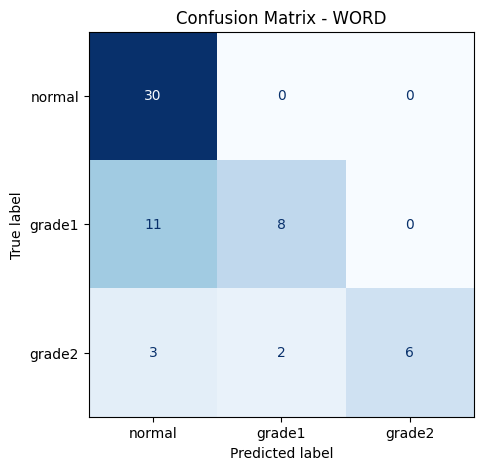


=== PWORD ===
Acc:0.736 Prec:0.679 Rec:0.655 F1:0.652 Kappa:0.572


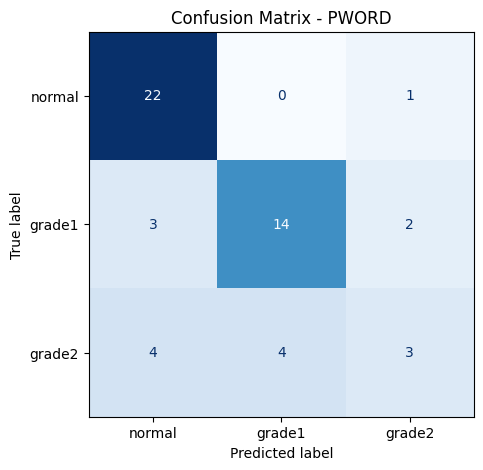


=== DWORD ===
Acc:0.640 Prec:0.756 Rec:0.563 F1:0.563 Kappa:0.403


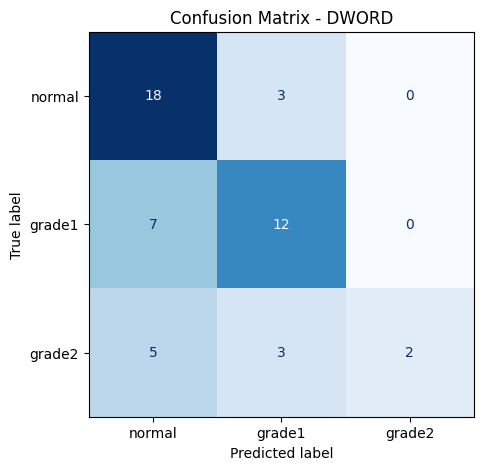


FINAL RESULT:
    Task  Accuracy  Precision    Recall        F1     Kappa
0   word  0.733333   0.827273  0.655502  0.689472  0.525692
1  pword  0.735849   0.678799  0.655364  0.651951  0.572088
2  dword  0.640000   0.755556  0.562907  0.562621  0.403183


In [ ]:
# =========================================================
# MULTIMODAL DYSGRAPHIA FINAL (PAPER STYLE)
# ONLINE SVM (TABLE II) + OFFLINE SVM (TABLE III)
# + CONFUSION MATRIX PER TASK
# =========================================================

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from PIL import Image
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ONLINE_ROOT = "/content/drive/MyDrive/DysgraphiaDB3/Online"
OFFLINE_ROOT = "/content/drive/MyDrive/DysgraphiaDB3/Offline_images"

# =========================
# PARAMETER (TABLE II & III)
# =========================
svm_online_params = {
    "pword": {"C":4, "gamma":0.015625, "kernel":"rbf"},
    "word": {"C":16, "gamma":0.015625, "kernel":"rbf"},
    "dword": {"C":4, "gamma":0.015625, "kernel":"rbf"}
}

svm_offline_params = {
    "pword": {"C":0.001953125, "gamma":0.015625, "kernel":"poly"},
    "word": {"C":0.001953125, "gamma":0.001953125, "kernel":"poly"},
    "dword": {"C":0.00390625, "gamma":0.0078125, "kernel":"poly"}
}

# =========================
# ONLINE FEATURE (PAPER)
# =========================
def extract_online_features(path):
    data = pd.read_csv(path, sep=r"\s+", header=None)

    x = data.iloc[:,0].values
    y = data.iloc[:,1].values
    t = data.iloc[:,2].values + 1e-5

    pressure = data.iloc[:,3].values if data.shape[1] > 3 else np.zeros(len(x))
    altitude = data.iloc[:,4].values if data.shape[1] > 4 else np.zeros(len(x))
    azimuth  = data.iloc[:,5].values if data.shape[1] > 5 else np.zeros(len(x))

    vx = np.diff(x) / np.diff(t)
    vy = np.diff(y) / np.diff(t)
    v = np.sqrt(vx**2 + vy**2)

    ax = np.diff(vx) / np.diff(t[:-1])
    ay = np.diff(vy) / np.diff(t[:-1])
    a = np.sqrt(ax**2 + ay**2)

    jx = np.diff(ax) / np.diff(t[:-2])
    jy = np.diff(ay) / np.diff(t[:-2])
    j = np.sqrt(jx**2 + jy**2)

    seg_len = np.sqrt(np.diff(x)**2 + np.diff(y)**2)

    def stats(arr):
        if len(arr) == 0:
            return [0,0,0,0]
        return [np.mean(arr), np.std(arr), np.max(arr), np.min(arr)]

    features = []
    features += stats(v)
    features += stats(a)
    features += stats(j)

    features += [
        np.sum(seg_len),
        np.sum(np.abs(np.diff(x))),
        np.sum(np.abs(np.diff(y))),
        t[-1] - t[0],
        np.max(x)-np.min(x),
        np.max(y)-np.min(y)
    ]

    features += [
        np.mean(pressure),
        np.std(pressure),
        np.mean(altitude),
        np.mean(azimuth)
    ]

    return np.array(features)

# =========================
# CNN FEATURE
# =========================
class CNNFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.densenet121(pretrained=True)
        self.features = base.features
        self.pool = nn.AdaptiveAvgPool2d((1,1))

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return torch.flatten(x,1)

transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

def extract_cnn(paths, model):
    feats = []
    model.eval()
    with torch.no_grad():
        for p in paths:
            img = Image.open(p).convert("RGB")
            img = transform(img).unsqueeze(0).to(device)
            feats.append(model(img).cpu().numpy().flatten())
    return np.array(feats)

# =========================
# METRICS
# =========================
def eval_metrics(y_true, y_pred):
    return (
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, average='macro', zero_division=0),
        recall_score(y_true, y_pred, average='macro', zero_division=0),
        f1_score(y_true, y_pred, average='macro', zero_division=0),
        cohen_kappa_score(y_true, y_pred)
    )

# =========================
# LOAD DATA
# =========================
def load_online(root):
    X, y, paths = [], [], []
    label_map = {"normal":0,"grade1":1,"grade2":2}

    for task in ["word","pword","dword"]:
        for cls in os.listdir(os.path.join(root,task)):
            path = os.path.join(root,task,cls)
            for r,_,files in os.walk(path):
                for f in files:
                    if f.endswith(".txt"):
                        p = os.path.join(r,f)
                        try:
                            X.append(extract_online_features(p))
                            y.append(label_map[cls])
                            paths.append(p)
                        except:
                            continue
    return np.array(X), np.array(y), paths

def load_offline(root):
    paths, labels = [], []
    label_map = {"normal":0,"grade1":1,"grade2":2}

    for task in ["word","pword","dword"]:
        for cls in os.listdir(os.path.join(root,task)):
            path = os.path.join(root,task,cls)
            for r,_,files in os.walk(path):
                for f in files:
                    if f.lower().endswith((".png",".jpg",".jpeg")):
                        paths.append(os.path.join(r,f))
                        labels.append(label_map[cls])
    return paths, np.array(labels)

# =========================
# MAIN
# =========================
X_online, y_online, _ = load_online(ONLINE_ROOT)
img_paths, _ = load_offline(OFFLINE_ROOT)

cnn_model = CNNFeatureExtractor().to(device)

tasks = ["word","pword","dword"]
results = []

for task in tasks:
    print(f"\n=== {task.upper()} ===")

    img_task = [p for p in img_paths if f"/{task}/" in p]

    min_len = min(len(img_task), len(X_online))
    X = X_online[:min_len]
    y = y_online[:min_len]
    img_task = img_task[:min_len]

    idx = np.arange(min_len)

    # SPLIT
    train_idx, temp_idx = train_test_split(idx, test_size=0.3, stratify=y, random_state=42)
    val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=y[temp_idx], random_state=42)

    # ONLINE
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X[train_idx])
    X_test  = scaler.transform(X[test_idx])

    y_train = y[train_idx]
    y_test  = y[test_idx]

    svm_online = SVC(**svm_online_params[task], probability=True)
    svm_online.fit(X_train, y_train)
    prob_online = svm_online.predict_proba(X_test)

    # OFFLINE
    img_train = [img_task[i] for i in train_idx]
    img_test  = [img_task[i] for i in test_idx]

    X_train_cnn = extract_cnn(img_train, cnn_model)
    X_test_cnn  = extract_cnn(img_test, cnn_model)

    scaler2 = StandardScaler()
    X_train_cnn = scaler2.fit_transform(X_train_cnn)
    X_test_cnn  = scaler2.transform(X_test_cnn)

    svm_offline = SVC(**svm_offline_params[task], probability=True)
    svm_offline.fit(X_train_cnn, y_train)
    prob_offline = svm_offline.predict_proba(X_test_cnn)

    # FUSION
    prob_final = (prob_online + prob_offline) / 2
    pred_test = np.argmax(prob_final, axis=1)

    acc, prec, rec, f1, kappa = eval_metrics(y_test, pred_test)

    print(f"Acc:{acc:.3f} Prec:{prec:.3f} Rec:{rec:.3f} F1:{f1:.3f} Kappa:{kappa:.3f}")

    # =========================
    # CONFUSION MATRIX
    # =========================
    cm = confusion_matrix(y_test, pred_test)

    fig, ax = plt.subplots(figsize=(5,5))
    disp = ConfusionMatrixDisplay(cm, display_labels=["normal","grade1","grade2"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)

    plt.title(f"Confusion Matrix - {task.upper()}")
    plt.show()

    results.append([task, acc, prec, rec, f1, kappa])

# =========================
# FINAL TABLE
# =========================
df = pd.DataFrame(results, columns=["Task","Accuracy","Precision","Recall","F1","Kappa"])

print("\nFINAL RESULT:")
print(df)

tanpa split

In [ ]:
for task in tasks:
    print(f"\n=== {task.upper()} ===")

    # filter offline
    img_task = [p for p in img_paths if f"/{task}/" in p]

    min_len = min(len(img_task), len(X_online))
    X = X_online[:min_len]
    y = y_online[:min_len]
    img_task = img_task[:min_len]

    # =========================
    # ONLINE MODEL (TRAIN = ALL)
    # =========================
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    svm_online = SVC(**svm_online_params[task], probability=True)
    svm_online.fit(X_scaled, y)

    prob_online = svm_online.predict_proba(X_scaled)

    # =========================
    # OFFLINE MODEL (TRAIN = ALL)
    # =========================
    X_cnn = extract_cnn(img_task, cnn_model)

    scaler2 = StandardScaler()
    X_cnn_scaled = scaler2.fit_transform(X_cnn)

    svm_offline = SVC(**svm_offline_params[task], probability=True)
    svm_offline.fit(X_cnn_scaled, y)

    prob_offline = svm_offline.predict_proba(X_cnn_scaled)

    # =========================
    # FUSION
    # =========================
    prob_final = (prob_online + prob_offline) / 2
    pred = np.argmax(prob_final, axis=1)

    # =========================
    # METRICS (ON TRAIN DATA)
    # =========================
    acc, prec, rec, f1, kappa = eval_metrics(y, pred)

    print(f"Acc:{acc:.3f} Prec:{prec:.3f} Rec:{rec:.3f} F1:{f1:.3f} Kappa:{kappa:.3f}")

    results.append([task, acc, prec, rec, f1, kappa])